Welcome!
In this notebook, we will try to generate multi-messenger lensed images/signals based on a simple model:
1. Firstly, we will set up a simple lens system and try to solve for lensing observables (image position $\vec{\theta}$, arrival time delay $t_d$, magnification $\mu$) of a simple point source using lenstronomy.
2. Then, we will try to produce simple lensed images of a galaxy.
3. Finally, we will inject a gravitational wave source (e.g., binary black hole merger) within the source galaxy, and produce lensed gravitational wave signals.

Let's start by importing basic packages and setting up conversion factors that may be useful.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

radian_to_arcsec = 180*3600/np.pi
arcsec_to_radian = np.pi/(180*3600)
mpc_to_meter = 3.086e22
c_Mpc_per_second = 3e8*3.24e-23 # Mpc/s
days_to_seconds = 24*3600

Now, we choose the lens model for the lens galaxy and set up basic parameters of the lens-source system: lens and source redshift $z_l$ & $z_s$, Einstein radius $\theta_E$ and lens specific parameters, such as axis ratio for SIE (singular isothermal ellipsoid) lens.

In [2]:
# import the LensModel class from lenstronomy
from lenstronomy.LensModel.lens_model import LensModel

# specify the choice of lens model(s)
lens_model_list = ['SIE'] 

# set source redshift
zs = 2. #BLANK
# set lens redshift
zl = 0.5 #BLANK

# set up lens model class with the list of lens model(s) used, with lens and source redshift included
lensModel = LensModel(lens_model_list=lens_model_list, z_lens=zl, z_source=zs)

One of the most important parameters of the lens is the Einstein radius  $\theta_E$, which gives the angular scale of the lens. We can either make up some number for it (typically, the order is 1 arcsecond), or for this SIE case here, we will calculate it from the velocity dispersion $v$ of the lens galaxy directly: $\theta_E = 4 \pi (v/c)^2 \frac{D_{ls}}{D_s}$ (in radian).

We also note that lenstronomy uses arcseconds as unit for Einstein radius.

In [3]:
# set SIE specific parameters
# (minor to major) axis ratio
f_axis_ratio = 0.5 #BLANK

# angle of major axis direction from East to North
phi = np.pi/2 #BLANK

# however, lenstronomy takes in e1 and e2 to quantify the ellipticity and orientation of the lens 
# convert axis ratio (f) and orientation angle (phi) of the lens to e1 and e2
import lenstronomy.Util.param_util as param_util
e1, e2 = param_util.phi_q2_ellipticity(phi=phi, q=f_axis_ratio)

# SIE velocity dispersion (in unit of c=1)
v_dispersion_dimensionless = 6e-4 #BLANK

# calculate Einstein radius of the lens system
# calculate angular diameter distances of the observer-lens-source system
# import cosmology
from astropy.cosmology import Planck18
Ds = Planck18.angular_diameter_distance(zs).value # In MPC
Dl = Planck18.angular_diameter_distance(zl).value # In MPC
Dls = Planck18.angular_diameter_distance_z1z2(zl, zs).value # In Mpc

# Einstein radius in arcseconds
ein_radius_arcsec = 4 * np.pi * (v_dispersion_dimensionless)**2 * Dls/Ds * radian_to_arcsec #BLANK

print('Einstein radius (arcsec) = ', ein_radius_arcsec)

Einstein radius (arcsec) =  0.5909618119660432


Now we have all the lens model parameters ready, let's store them into a list called 'kwargs_lens', which we will feed into lenstronomy for lensing calculation later.

In [4]:
kwargs_sie = {'theta_E':ein_radius_arcsec , 'e1': e1, 'e2': e2, 'center_x': 0, 'center_y': 0} #BLANK
kwargs_lens = [kwargs_sie]

Now let's setup a point source and calculate the lensing observables. The only additionaly parameters we need is source position $\vec{\beta}$ in arcseconds (or dimensionless source position $\vec{y}$, scaled by Einstein radius $\theta_E$).

In [5]:
# set (angular) source position (dimensionless, scaled by Einstein radius)
source_y_ra_dimensionless = 0.1 #BLANK
source_y_dec_dimensionless = 0.2 #BLANK

# calculate (angular) source position in arcsec
source_beta_ra_arcsec = source_y_ra_dimensionless * ein_radius_arcsec #BLANK
source_beta_dec_arcsec = source_y_dec_dimensionless * ein_radius_arcsec #BLANK

We can then solve for the image position $\theta$ (in arcseconds) by solving the lens equation: $\vec{\beta}=\vec{\theta}-\nabla \psi$. Note that lenstronomy takes in source position in units of arcseconds.

In [6]:
# import the LensEquationSolver class from lenstronomy
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver

# solve for image positions (image_theta_ra/dec_arcsec) provided a lens model (lensModel class), lens model parameters (kwargs_lens) and the source position (source_beta_ra/dec_arcsec)
solver = LensEquationSolver(lensModel)
image_theta_ra_arcsec, image_theta_dec_arcsec = solver.image_position_from_source(source_beta_ra_arcsec, 
                                                                                  source_beta_dec_arcsec, 
                                                                                  kwargs_lens, 
                                                                                  solver='lenstronomy', 
                                                                                  magnification_limit=1e-1, 
                                                                                  search_window=8, 
                                                                                  precision_limit=1e-15, 
                                                                                  min_distance=0.01, 
                                                                                  num_iter_max=500, 
                                                                                  arrival_time_sort=True, 
                                                                                  initial_guess_cut=True, 
                                                                                  verbose=False)

for i in range(len(image_theta_ra_arcsec)):
    print('Image position (ra, dec) for image', i+1, ' in arcsec:', image_theta_ra_arcsec[i], image_theta_dec_arcsec[i])

Image position (ra, dec) for image 1  in arcsec: 0.6576506544498112 0.290892237080308
Image position (ra, dec) for image 2  in arcsec: -0.44578965512791585 0.42900057252598794
Image position (ra, dec) for image 3  in arcsec: -0.19904125708623707 0.5815550059700003
Image position (ra, dec) for image 4  in arcsec: -0.050846473548748966 -0.37980466935210794


Then, we can calculate the magnification $\mu$ of each images. Only image positions and lens model are required.

In [7]:
image_magnification = lensModel.magnification(image_theta_ra_arcsec, image_theta_dec_arcsec, kwargs_lens)

for i in range(len(image_theta_ra_arcsec)):
    print('Magnification for image', i+1, ':', image_magnification[i])

Magnification for image 1 : 2.6344388661747318
Magnification for image 2 : 6.438406936509682
Magnification for image 3 : -5.380043143718121
Magnification for image 4 : -0.8884228521305962


And similarly for the arrival time of the images. We further calculate the time delay $t_d$ with respect to the first image.

In [8]:
image_arrival_time = lensModel.arrival_time(x_image=image_theta_ra_arcsec, y_image=image_theta_dec_arcsec, x_source=source_beta_ra_arcsec, y_source=source_beta_dec_arcsec, kwargs_lens=kwargs_lens)

# set the first image's arrival time as reference time
image_arrival_time = image_arrival_time - image_arrival_time[0]

for i in range(len(image_theta_ra_arcsec)):
    print('Arrival time delay for image', i+1, ':', image_arrival_time[i], 'days')

Arrival time delay for image 1 : 0.0 days
Arrival time delay for image 2 : 5.780911851795262 days
Arrival time delay for image 3 : 5.993738860899182 days
Arrival time delay for image 4 : 15.932601597739673 days


Finally, we can plot the image positions on the lens plane. 

In the figure below: 
1. The size of the image represents the magnification.
2. The colour map represents the 2D density profile
3. The smooth black curve is critical curve on the image plane, which when the images are produced near or on it, they will have near-infinite magnification. It is also where multiple images (2/3) merge and possibly disappear.
4. The inner diamond shape curve is the caustic, whic is the critical curve mapped back to the source plane, with the yellow star being the source position on the source plane.

Try to modify the lens model or change the source position, and see what will happen if the source crosses the caustic!

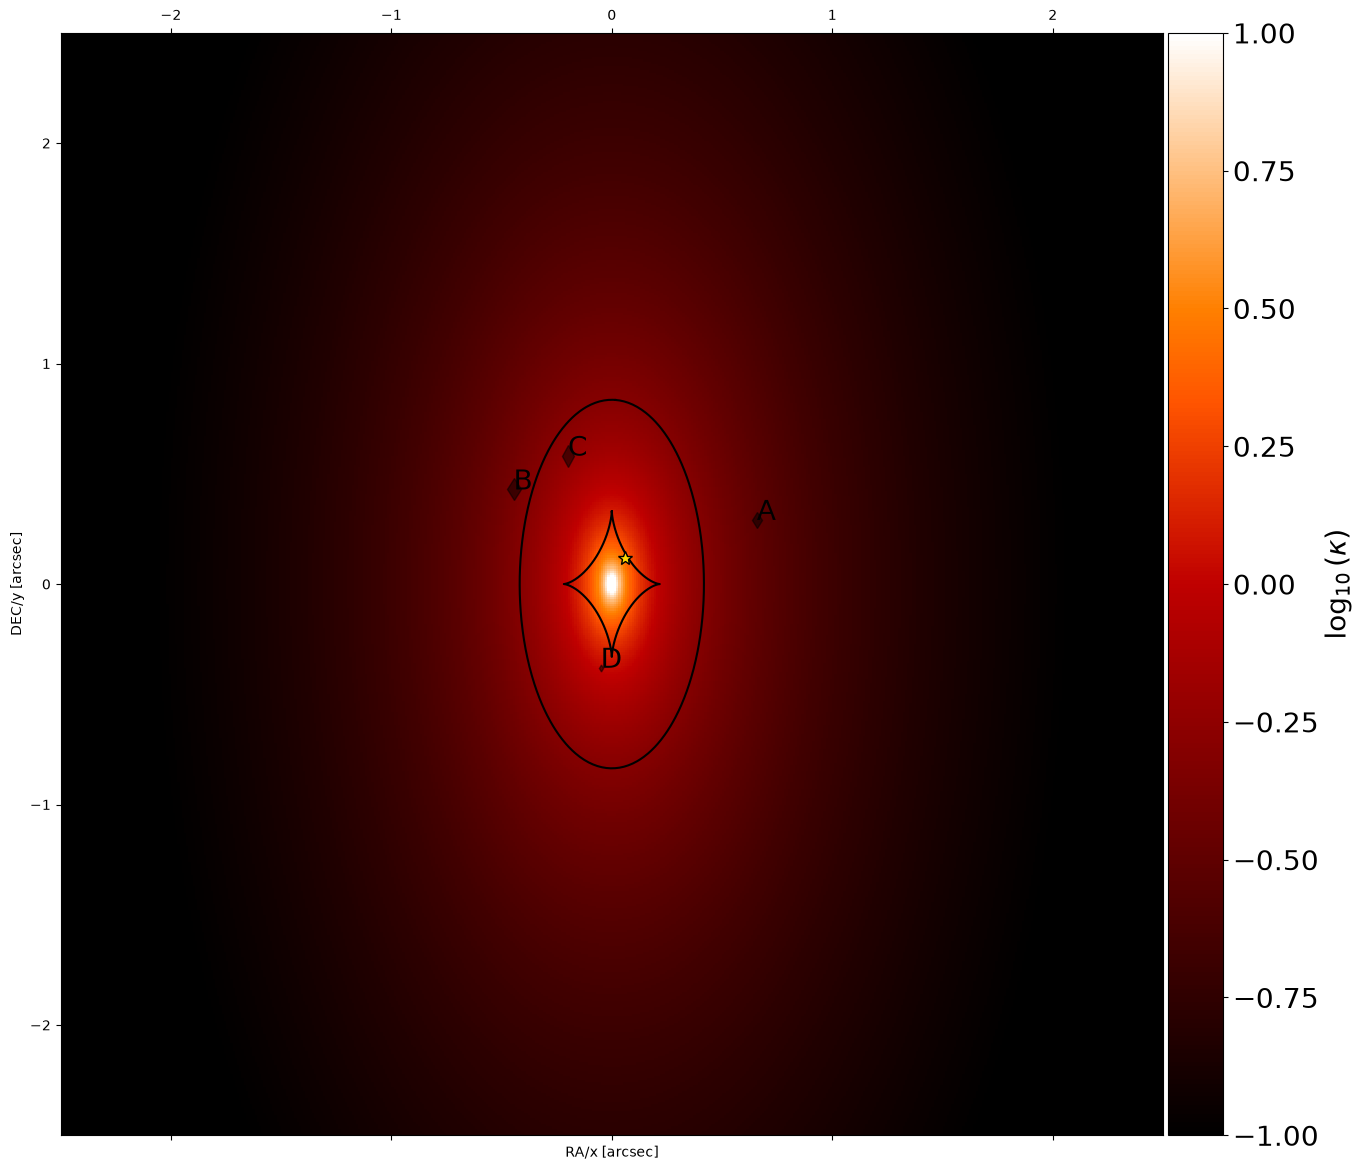

In [9]:
from lenstronomy.Plots import lens_plot
fig, axex = plt.subplots(1, 1, figsize=(15, 15), sharex=False, sharey=False)
lens_plot.lens_model_plot(axex, 
                          lens_model=lensModel, 
                          kwargs_lens=kwargs_lens, 
                          source_pos_x=source_beta_ra_arcsec, 
                          source_pos_y=source_beta_dec_arcsec, 
                          point_source=True, 
                          fast_caustic=True,
                          coord_inverse=False, 
                          with_convergence=True)
fig.show()

Let's produce a lensed image of a source galaxy, just like the images that we saw in the slides.

For simplicity, we will only need to set up the lens and source galaxy light profile. We will neglect the noise of the telescope.

We will be using a Sersic light profile for both the lens and the source. The main parameters are the half light radius $R_\text{Sersic}$ and Sersic index $n$. The intensity goes as: $I(r)=I_0 e^{[-b_n (r/R_\text{Sersic})^{1/n}]}$, where $b_n$ is defined to ensure half the light is confined at $r<R_\text{Sersic}$ (at $0.5<n<10$, we have $b_n \approx 1.999n-0.327$).

Feel free to google for some parameters for real galaxies. Let's set things up for the source galaxy first. We note that lenstronomy takes in angular $R_\text{Sersic}$ in units of arcseconds.

In [10]:
# import the LightModel class from lenstronomy
from lenstronomy.LightModel.light_model import LightModel
# set up light model(s) to be used for the source
source_light_model_list = ['SERSIC']
lightModel_source = LightModel(light_model_list=source_light_model_list)

# set up parameters for the source light model
# set half light radius (in MPC)
source_R_sersic_MPC = 0.01 #BLANK # typical elliptical galaxy
# obtain (angular) half light radius in arcsec
source_R_sersic_arcsec = source_R_sersic_MPC/Ds*radian_to_arcsec #BLANK
# set Sersic index
source_n_sersic = 4 #BLANK # typical elliptical galaxy
print('R_sersic = ', source_R_sersic_arcsec, 'arcsec')
# set source amplitude
# absolute amplitude does not matter much here, just make sure this and the lens galaxy amplitude is comparable
source_amp = 100 #BLANK

# feed the parameters into a list
# align the light source's center to the point source position we used above
kwargs_light_source = [{'amp': source_amp, 
                        'R_sersic': source_R_sersic_arcsec, 
                        'n_sersic': source_n_sersic, 
                        'center_x': source_beta_ra_arcsec, 
                        'center_y': source_beta_dec_arcsec}] #BLANK

R_sersic =  1.1657354933614184 arcsec


Let's do the same for lens galaxy, and we choose a elliptical Sersic profile here. The detailed parameters do not matter too much, as we are focusing on the lensed source galaxy.

In [11]:
lens_light_model_list = ['SERSIC_ELLIPSE']
lightModel_lens = LightModel(light_model_list=lens_light_model_list)

kwargs_light_lens = [{'amp': 100, 
                      'R_sersic': source_R_sersic_MPC/Dl*radian_to_arcsec, 
                      'n_sersic': 4, 
                      'e1': e1, 'e2': e2, 
                      'center_x': 0, 'center_y': 0}] #BLANK

Now we set up the pixel grid.

In [12]:
# import the PixelGrid class
from lenstronomy.Data.pixel_grid import PixelGrid
deltaPix = 0.001  # size of (angular) pixel in arcseconds

# set up the keyword arguments to create the Data class
# set the size of the image plot (in arcseconds)
size_ra = 3 #BLANK
size_dec = size_ra

ra_at_xy_0, dec_at_xy_0 = -size_ra/2, -size_dec/2 # angular coordinate (RA/DEC) in arcseconds at the position of the pixel edge (0,0)
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix  # linear translation matrix of a shift in pixel in a shift in coordinates
kwargs_pixel = {'nx': int(size_ra/deltaPix), 'ny': int(size_dec/deltaPix),  # number of pixels per axis
                'ra_at_xy_0': ra_at_xy_0,  # RA at pixel (0,0)
                'dec_at_xy_0': dec_at_xy_0,  # DEC at pixel (0,0)
                'transform_pix2angle': transform_pix2angle} 
pixel_grid = PixelGrid(**kwargs_pixel)
# return the list of pixel coordinates
x_coords, y_coords = pixel_grid.pixel_coordinates

When light goes into telescope, there will be a small diffraction effect, which the light will 'spread' across pixels. This is quantified by the FWHM (full width at half maximum) of the PSF (point spread function). For telescopes, we have to always account for that. For simplicity, we can set FWHM to be 0.1 arcseconds, which roughly corresponds to Hubble Space Telescope at visible light range.

In [13]:
# import the PSF class
from lenstronomy.Data.psf import PSF
kwargs_psf = {'psf_type': 'GAUSSIAN',  # type of PSF model
              'fwhm': 0.1,  #BLANK # full width at half maximum of the Gaussian PSF (in arcseconds) 
              'pixel_size': deltaPix  # angular scale of a pixel (required for a Gaussian PSF to translate the FWHM into a pixel scale)
             }
psf = PSF(**kwargs_psf)
# return the pixel kernel corresponding to a point source 
kernel = psf.kernel_point_source

Let's generate the image.

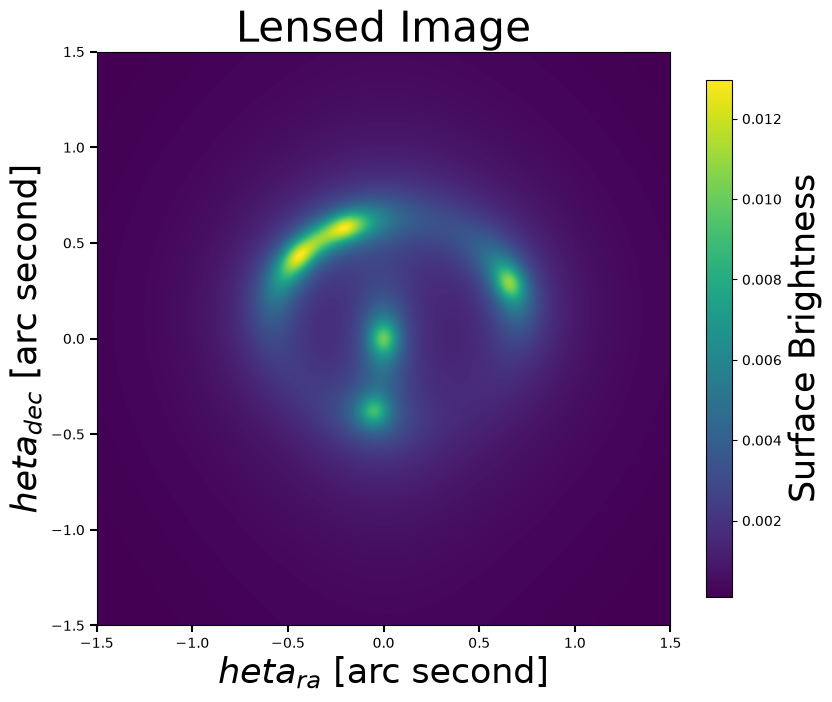

In [14]:
# import the ImageModel class from lenstronomy
from lenstronomy.ImSim.image_model import ImageModel
# define the numerics
kwargs_numerics = {'supersampling_factor': 1, # each pixel gets super-sampled (in each axis direction) 
                  'supersampling_convolution': False}
# initialize the Image model class by combining the modules we created above
imageModel = ImageModel(data_class=pixel_grid, psf_class=psf, lens_model_class=lensModel,
                        source_model_class=lightModel_source,
                        lens_light_model_class=lightModel_lens,
                        point_source_class=None,
                        kwargs_numerics=kwargs_numerics)
# simulate image with the parameters we have defined above
image = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_light_source,
                         kwargs_lens_light=kwargs_light_lens)

#import scienceplots
x_upper_lim_arcsec = size_ra/2
x_lower_lim_arcsec = -size_ra/2
y_upper_lim_arcsec = size_dec/2
y_lower_lim_arcsec = -size_dec/2

# image plotting width
plot_x_width = int(size_ra/deltaPix)
plot_y_width = int(size_dec/deltaPix)
plot_x_upper_lim = x_upper_lim_arcsec
plot_x_lower_lim = x_lower_lim_arcsec
plot_y_upper_lim = y_upper_lim_arcsec
plot_y_lower_lim = y_lower_lim_arcsec

f, axes = plt.subplots(figsize=(8, 8), sharex=False, sharey=False)
img = axes.imshow((image), origin='lower', extent=[x_lower_lim_arcsec, x_upper_lim_arcsec, y_lower_lim_arcsec, y_upper_lim_arcsec])
axes.set_xlim(plot_x_lower_lim, plot_x_upper_lim)
axes.set_ylim(plot_y_lower_lim, plot_y_upper_lim)
axes.tick_params(which='major', length=5 , width=1.5)
f.tight_layout()

plt.title("Lensed Image", fontsize=30)
plt.xlabel("$\theta_{ra}$ [arc second]", fontsize=25)
plt.ylabel("$\theta_{dec}$ [arc second]", fontsize=25)
mpl.rcParams['axes.labelsize'] = 25
plt.colorbar(img, shrink=0.7, label='Surface Brightness')

plt.show()


Congrats! You have successfully simulated a galaxy-galaxy EM lens system.

Let's move on to gravitational wave lensing. We will assume the GW originates from the same source galaxy above and goes through the same physical process of gravitational lensing by the same lens.

To start with, we should set up the source position $\vec{\beta}$ of the GW. It should not be far off from the source position of the (center) of the source galaxy.

In [15]:
# set up source position for GW source
# assume GW source is within the source galaxy above
GW_source_y_ra_dimensionless = 0.1 #BLANK
GW_source_y_dec_dimensionless = 0.2 #BLANK

# calculate (angular) GW source position in arcsec
GW_source_beta_ra_arcsec = GW_source_y_ra_dimensionless * ein_radius_arcsec #BLANK
GW_source_beta_dec_arcsec = GW_source_y_dec_dimensionless * ein_radius_arcsec #BLANK

Now, we go through the same steps of solving the lens equation to calculate the lensing observables for the GW (image position $\vec{\theta}$, arrival time delay $t_d$, magnification $\mu$), which can be treated as a point source.

In [16]:
solver = LensEquationSolver(lensModel) #BLANK
GW_image_theta_ra_arcsec, GW_image_theta_dec_arcsec = solver.image_position_from_source(GW_source_beta_ra_arcsec, 
                                                                                  GW_source_beta_dec_arcsec, 
                                                                                  kwargs_lens, 
                                                                                  solver='lenstronomy', 
                                                                                  magnification_limit=1e-1, 
                                                                                  search_window=8, 
                                                                                  precision_limit=1e-15, 
                                                                                  min_distance=0.01, 
                                                                                  num_iter_max=500, 
                                                                                  arrival_time_sort=True, 
                                                                                  initial_guess_cut=True, 
                                                                                  verbose=False)

GW_image_magnification = lensModel.magnification(GW_image_theta_ra_arcsec, GW_image_theta_dec_arcsec, kwargs_lens) #BLANK

GW_image_arrival_time = lensModel.arrival_time(x_image=GW_image_theta_ra_arcsec, y_image=GW_image_theta_dec_arcsec, x_source=GW_source_beta_ra_arcsec, y_source=GW_source_beta_dec_arcsec, kwargs_lens=kwargs_lens) #BLANK

# set the first image's arrival time as reference time
GW_image_arrival_time = GW_image_arrival_time - GW_image_arrival_time[0] #BLANK

GW_image_arrival_time_s = GW_image_arrival_time*days_to_seconds

for i in range(len(GW_image_theta_ra_arcsec)):
    print('For GW image', i+1, ', image position (ra, dec) in arcsec:', GW_image_theta_ra_arcsec[i], GW_image_theta_dec_arcsec[i], 
          ', magnification:', GW_image_magnification[i], 
          ', arrival time delay:', GW_image_arrival_time[i], 'days or ', GW_image_arrival_time_s[i],'seconds')

For GW image 1 , image position (ra, dec) in arcsec: 0.6576506544498112 0.290892237080308 , magnification: 2.6344388661747318 , arrival time delay: 0.0 days or  0.0 seconds
For GW image 2 , image position (ra, dec) in arcsec: -0.44578965512791585 0.42900057252598794 , magnification: 6.438406936509682 , arrival time delay: 5.780911851795262 days or  499470.7839951106 seconds
For GW image 3 , image position (ra, dec) in arcsec: -0.19904125708623707 0.5815550059700003 , magnification: -5.380043143718121 , arrival time delay: 5.993738860899182 days or  517859.0375816893 seconds
For GW image 4 , image position (ra, dec) in arcsec: -0.050846473548748966 -0.37980466935210794 , magnification: -0.8884228521305962 , arrival time delay: 15.932601597739673 days or  1376576.7780447078 seconds


Unlike in EM lensing where morse index/image type is not really of point of interest, in GW, it can change the waveform of the lensed signal. Therefore, we should obtain the morse index of the lensed signals.

We note that the morse index of the image is encoded in the sign of the magnification. Since type 3 image (local maximum) is too faint, we don't need to consider it here. Therefore, if $\mu>0$, it is type 1 (local minimum) and morse index $n=0$. If $\mu<0$, it is type 2 (saddle point) and morse index $n=0.5$.

In [17]:
GW_morse_index_n = np.empty(len(GW_image_theta_ra_arcsec))

for i in range(len(GW_image_theta_ra_arcsec)): #BLANK
    if GW_image_magnification[i]>0:
        GW_morse_index_n[i] = 0
    else:
        GW_morse_index_n[i] = 0.5 

print('Morse index n of the', len(GW_image_theta_ra_arcsec), 'image(s):', GW_morse_index_n)

Morse index n of the 4 image(s): [0.  0.  0.5 0.5]


After obtaining all the lensing observables of the GW, let's actually set up the GW parameters and generate the lensed GW with Bilby.

In [18]:
import bilby
from bilby.core.utils.random import seed
from bilby.gw.detector import get_empty_interferometer
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.waveform_generator import WaveformGenerator

We can set the parameters for the BBH merger here, just choose any parameters that are reasonable.

In [19]:
injection_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.4,
    a_2=0.3, 
    tilt_1=0.5,
    tilt_2=1.0,
    phi_12=1.7,
    phi_jl=0.3,
    luminosity_distance=Planck18.luminosity_distance(zs).value, # in MPC # need to fit zs
    theta_jn=0.4,
    psi=2.659,
    phase=1.3,
    geocent_time=0,
    ra=0,
    dec=0,
) #BLANK

As different lensed signals are days, weeks or even months apart, it does not make sense to plot all the lensed GW signal $h_{\text{lensed}}(t)$ as a whole in the time domain together. So here, we just look at the individual signal $h_{\text{lensed}, j}(t)$ and compare it iwith the unlensed signal.

Let's generate the original unlensed GW first.

In [20]:
duration = 15 # in seconds, make sure this covers the whole signal
sampling_frequency = 2048.0 # in Hz

waveform_arguments = dict(
    waveform_approximant="IMRPhenomTPHM", reference_frequency=50.0
)

waveform_generator = WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_black_hole,
    parameters=injection_parameters,
    waveform_arguments=waveform_arguments,
)

02:14 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=15, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomTPHM', 'reference_frequency': 50.0})


Now, we can obtain the unlensed GW in frequency domain $h_{\text{original}}(f)$, for both $+$ and $\times$ polarization. Sometimes it is easier to apply the lensing effect in frequency domain instead of time domain.

In [21]:
hf_signal = waveform_generator.frequency_domain_strain(injection_parameters)

frequencies = waveform_generator.frequency_array

hf_signal_plus = hf_signal['plus']
hf_signal_cross = hf_signal['cross']

/home/jason/surip-summer-school-2026/strong_lensing/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Now, let's select one specific image and compute the lensed GW signal in frequency domain $h_{\text{lensed},j}(f)$.

The lensed and original waveform in frequency domain is related by $h_{\text{lensed}}(f)=h_{\text{original}}(f)\times \sum_j \sqrt{|\mu_j|} e^{-(2 \pi i f t_{d,j}-i \pi n_j)}$ (we note there is a extra negative sign in the argument of the exponential function compared to most literature, but that is just because of how Fourier transform is defined in Bilby).

Since we are focusing on one specific image $j$, we just have $h_{\text{lensed},j}(f)=h_{\text{original}}(f)\times \sqrt{|\mu_j|} e^{-(2 \pi i f t_{d,j}-i \pi n_j)}$. The arrival time also will not matter here, so we can just set $t_{d,j}$ to be any value. In the code below, we set it to be equal to 't_start_buffer', which is just for the purpose of avoiding the Fourier transform from chopping up the GW signal when it is transformed back into time domain.

In [22]:
hf_lensed_signal_1_image_plus = np.empty(len(frequencies), dtype=complex)
hf_lensed_signal_1_image_cross = np.empty(len(frequencies), dtype=complex)

t_start_buffer = 10 # in seconds

image_no = 2 #BLANK

hf_lensed_signal_1_image_plus = hf_signal_plus*np.sqrt(np.abs(GW_image_magnification[image_no-1]))*np.exp(-2*np.pi*1j*frequencies*t_start_buffer+1j*np.pi*GW_morse_index_n[image_no-1]) #BLANK
hf_lensed_signal_1_image_cross = hf_signal_cross*np.sqrt(np.abs(GW_image_magnification[image_no-1]))*np.exp(-2*np.pi*1j*frequencies*t_start_buffer+1j*np.pi*GW_morse_index_n[image_no-1]) #BLANK

hf_lensed_signal_1_image = {"plus": hf_lensed_signal_1_image_plus, "cross": hf_lensed_signal_1_image_cross}

Then we can compute and plot the lensed GW signal of the specific chosen image $j$ in time domain $h_{\text{lensed},j}(t)$.

In [23]:
ht_lensed_signal_1_image_plus = bilby.core.utils.infft(hf_lensed_signal_1_image_plus, sampling_frequency)
ht_lensed_signal_1_image_cross = bilby.core.utils.infft(hf_lensed_signal_1_image_cross, sampling_frequency)
time_lensed_signal = waveform_generator.time_array

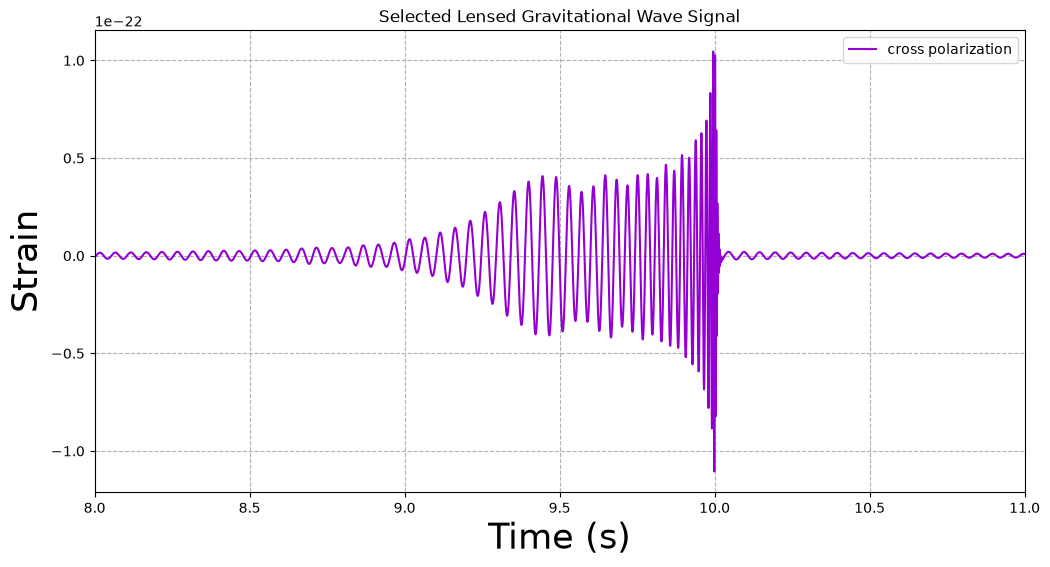

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(time_lensed_signal, ht_lensed_signal_1_image_plus.real, color='darkviolet', label='plus polarization')
plt.xlim(8,11)
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Selected Lensed Gravitational Wave Signal')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

Now let's align the original unlensed GW signal at the same arrival time and compare the two. Try to see what are the differences and similarities between the signals. Also, what are the differences between the type 1 and type 2 signals?

In [25]:
hf_signal_unlensed_plus = hf_signal_plus*np.exp(-2*np.pi*1j*frequencies*t_start_buffer)
hf_signal_unlensed_cross = hf_signal_cross*np.exp(-2*np.pi*1j*frequencies*t_start_buffer)

hf_signal_unlensed = {"plus": hf_signal_unlensed_plus, "cross": hf_signal_unlensed_cross}

ht_unlensed_signal_plus = bilby.core.utils.infft(hf_signal_unlensed_plus, sampling_frequency)
ht_unlensed_signal_cross = bilby.core.utils.infft(hf_signal_unlensed_cross, sampling_frequency)
time_unlensed_signal = waveform_generator.time_array

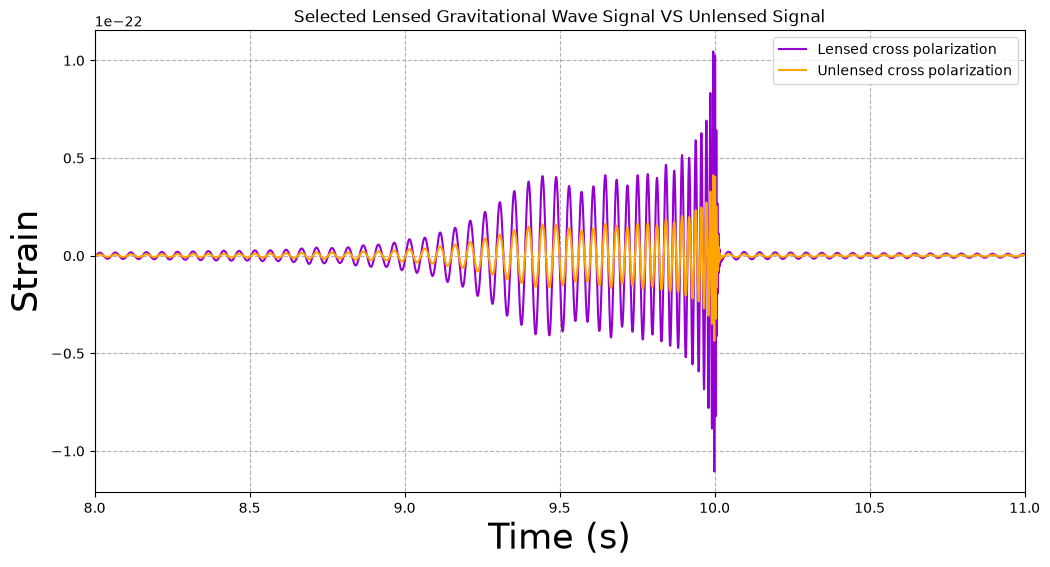

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(time_lensed_signal, ht_lensed_signal_1_image_plus.real, color='darkviolet', label='Lensed plus polarization')
plt.plot(time_unlensed_signal, ht_unlensed_signal_plus.real, color='orange', label='Unlensed plus polarization')
plt.xlim(8,11)
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Selected Lensed Gravitational Wave Signal VS Unlensed Signal')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()